# Heston FFT Pricer Demo

This notebook demonstrates the usage of the Heston FFT Pricer project.
We will compare the **FFT (Carr-Madan)** method with a **Monte Carlo** simulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from src.models.heston import HestonModel
from src.pricing.fft import price_option_fft
from src.pricing.monte_carlo import price_option_mc

## 1. Model Configuration

We define the Heston model parameters.

In [2]:
params = {
    "S0": 100.0,    # Spot Price
    "v0": 0.04,     # Initial Variance
    "r": 0.03,      # Risk-Free Rate
    "kappa": 2.0,   # Mean Reversion Speed
    "theta": 0.04,  # Long-Term Variance
    "sigma": 0.3,   # Vol of Vol
    "rho": -0.7,    # Correlation
    "T": 1.0,       # Time to Maturity
    "K": 100.0      # Strike Price
}

model = HestonModel(
    S0=params["S0"], v0=params["v0"], r=params["r"],
    kappa=params["kappa"], theta=params["theta"], 
    sigma=params["sigma"], rho=params["rho"]
)

print("Model initialized:", model)

Model initialized: HestonModel(S0=100.0, v0=0.04, r=0.03, kappa=2.0, theta=0.04, sigma=0.3, rho=-0.7)


## 2. Pricing Benchmark

We calculate the reference price using the FFT method.

In [3]:
t0 = time.time()
price_fft = price_option_fft(model, K=params["K"], T=params["T"])
dt_fft = time.time() - t0

print(f"FFT Price: {price_fft:.6f}")
print(f"Time: {dt_fft:.6f}s")

FFT Price: 9.242521
Time: 0.005414s


## 3. Monte Carlo Convergence

We run the Monte Carlo simulation with an increasing number of paths to see the convergence.

In [4]:
path_steps = [1000, 5000, 10000, 50000, 100000]
mc_prices = []
times = []

# Warmup Numba
price_option_mc(model, params["K"], params["T"], num_paths=100, num_steps=10)

print("Running simulations...")
for n in path_steps:
    t0 = time.time()
    p = price_option_mc(model, params["K"], params["T"], num_paths=n, num_steps=100)
    dt = time.time() - t0
    mc_prices.append(p)
    times.append(dt)
    print(f"Paths: {n:6d} | Price: {p:.6f} | Time: {dt:.4f}s")

Running simulations...
Paths:   1000 | Price: 8.402874 | Time: 0.0022s
Paths:   5000 | Price: 9.174077 | Time: 0.0068s
Paths:  10000 | Price: 9.266771 | Time: 0.0123s
Paths:  50000 | Price: 9.282436 | Time: 0.0640s


Paths: 100000 | Price: 9.193490 | Time: 0.1915s


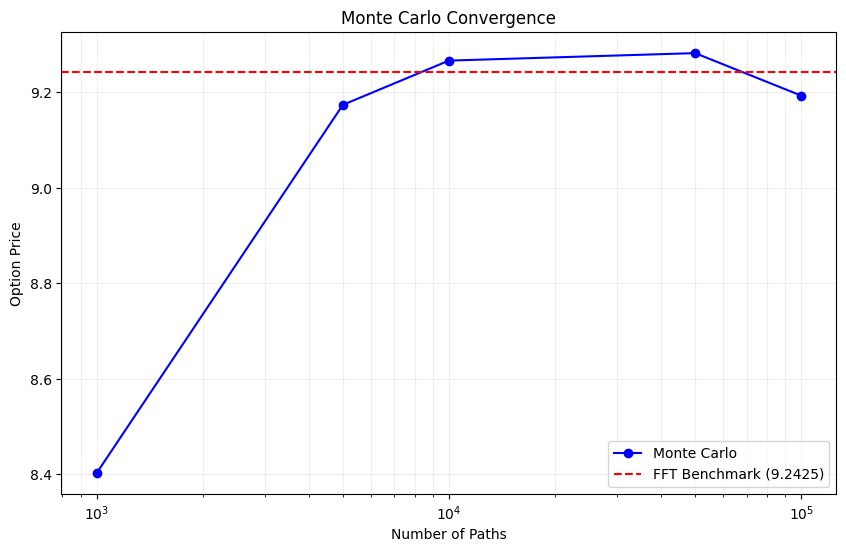

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(path_steps, mc_prices, 'b-o', label='Monte Carlo')
plt.axhline(y=price_fft, color='r', linestyle='--', label=f'FFT Benchmark ({price_fft:.4f})')
plt.xscale('log')
plt.xlabel('Number of Paths')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## 4. Price Surface

We visualize the option price as a function of Strike ($K$) and Maturity ($T$).

Calculating Price Surface...


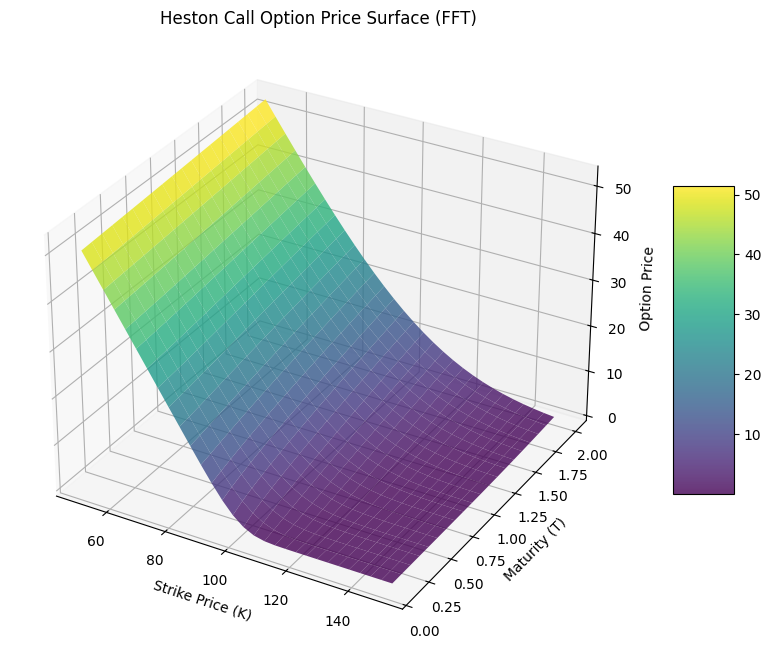

In [6]:
strikes = np.linspace(model.S0 * 0.5, model.S0 * 1.5, 30)
maturities = np.linspace(0.1, 2.0, 20)

K_grid, T_grid = np.meshgrid(strikes, maturities)
prices = np.zeros_like(K_grid)

print("Calculating Price Surface...")
for i in range(len(maturities)):
    for j in range(len(strikes)):
        prices[i, j] = price_option_fft(model, strikes[j], maturities[i])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    K_grid, T_grid, prices, 
    cmap='viridis', 
    edgecolor='none',
    alpha=0.8
)

ax.set_xlabel('Strike Price (K)')
ax.set_ylabel('Maturity (T)')
ax.set_zlabel('Option Price')
ax.set_title('Heston Call Option Price Surface (FFT)')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()